# Visualización: Convergencia y Evolución de Tabu Search

Este notebook carga `csv_final/convergence_data.csv` y `csv_final/ts_evolution_single_restart.csv` y genera dos gráficos (PNG) guardados en `csv_final/`.

In [1]:
# ----------------------- #
# UPDATE PATH DEFINITIONS #
# ----------------------- #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style='whitegrid')

csv_dir = Path('../csv_final')
convergence_path = csv_dir / 'convergence_data.csv'
ts_evolution_path = csv_dir / 'ts_evolution_single_restart.csv'

print('convergence_path:', convergence_path)
print('ts_evolution_path:', ts_evolution_path)

convergence_path: ../csv_final/convergence_data.csv
ts_evolution_path: ../csv_final/ts_evolution_single_restart.csv


In [2]:
csv_dir.mkdir(parents=True, exist_ok=True)
if not convergence_path.exists():
    raise FileNotFoundError(f'Convergence CSV not found: {convergence_path}')
if not ts_evolution_path.exists():
    raise FileNotFoundError(f'TS evolution CSV not found: {ts_evolution_path}')
df_conv = pd.read_csv(convergence_path)
df_ts = pd.read_csv(ts_evolution_path)
df_conv['Elapsed_Time'] = pd.to_numeric(df_conv['Elapsed_Time'], errors='coerce')
df_conv['Best_Objective'] = pd.to_numeric(df_conv['Best_Objective'], errors='coerce')
df_ts['iteration_number'] = pd.to_numeric(df_ts['iteration_number'], errors='coerce').astype('Int64')
df_ts['current_solution_objective'] = pd.to_numeric(df_ts['current_solution_objective'], errors='coerce')
df_ts['global_best_objective'] = pd.to_numeric(df_ts['global_best_objective'], errors='coerce')
df_ts['was_worsening_move'] = df_ts['was_worsening_move'].astype(str).str.lower().isin(['true','1','t','yes'])
print('Convergence head:')
print(df_conv.head().to_string(index=False))
print('')
print('TS evolution head:')
print(df_ts.head().to_string(index=False))

Convergence head:
Algorithm  Elapsed_Time  Best_Objective
    GRASP      0.851142         7603.27
    GRASP      3.111197         7640.81
    GRASP      6.810420         7645.07
    GRASP     11.303646         7674.79
    GRASP     22.907990         7719.41

TS evolution head:
 iteration_number  current_solution_objective  global_best_objective  was_worsening_move
                1                     6206.10                6206.10               False
                2                     6307.19                6307.19               False
                3                     6390.19                6390.19               False
                4                     6465.98                6465.98               False
                5                     6538.45                6538.45               False


In [3]:
def compute_auc(events_df, time_horizon=None):
    if events_df.empty:
        return 0.0
    if time_horizon is None:
        time_horizon = float(events_df['Elapsed_Time'].max())
    times = [0.0] + events_df['Elapsed_Time'].tolist()
    values = events_df['Best_Objective'].tolist()
    initial = values[0]
    vals = [initial] + values
    if times[-1] < time_horizon:
        times.append(time_horizon)
        vals.append(vals[-1])
    area = 0.0
    for i in range(len(times)-1):
        area += vals[i] * (times[i+1] - times[i])
    return area

time_horizon = float(df_conv['Elapsed_Time'].max()) if not df_conv.empty else 0.0
metrics = []
for algo in df_conv['Algorithm'].unique():
    df_a = df_conv[df_conv['Algorithm']==algo].sort_values('Elapsed_Time')
    n_impr = len(df_a)
    t_first = float(df_a['Elapsed_Time'].iloc[0]) if n_impr>0 else float('nan')
    final_best = float(df_a['Best_Objective'].iloc[-1]) if n_impr>0 else float('nan')
    auc = compute_auc(df_a, time_horizon=time_horizon) if n_impr>0 else 0.0
    metrics.append({'Algorithm':algo, 'n_improvements':n_impr, 'time_first_improvement':t_first, 'final_best':final_best, 'auc':auc})
metrics_df = pd.DataFrame(metrics)
print('')
print('Summary metrics:')
print(metrics_df.to_string(index=False))


Summary metrics:
Algorithm  n_improvements  time_first_improvement  final_best           auc
    GRASP               6                0.851142     7728.74 925285.158844
 GRASP+TS               1              120.027063     7771.66 932809.524435


Convergence plot saved to: ../csv_final/convergence_plot.png


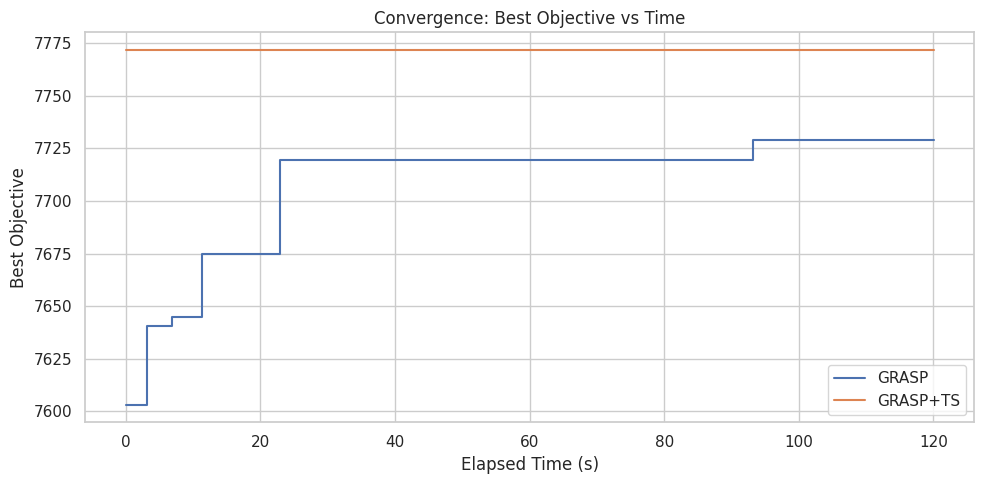

In [4]:
plt.figure(figsize=(10,5))
for algo in df_conv['Algorithm'].unique():
    df_a = df_conv[df_conv['Algorithm']==algo].sort_values('Elapsed_Time')
    if df_a.empty:
        continue
    time_h = time_horizon
    times = [0.0] + df_a['Elapsed_Time'].tolist()
    values = [df_a['Best_Objective'].iloc[0]] + df_a['Best_Objective'].tolist()
    if times[-1] < time_h:
        times.append(time_h)
        values.append(values[-1])
    plt.step(times, values, where='post', label=f'{algo}')
plt.xlabel('Elapsed Time (s)')
plt.ylabel('Best Objective')
plt.title('Convergence: Best Objective vs Time')
plt.legend()
plt.tight_layout()
conv_plot_path = csv_dir / 'convergence_plot.png'
plt.savefig(conv_plot_path, dpi=200)
print(f'Convergence plot saved to: {conv_plot_path}')
plt.show()

TS evolution plot saved to: ../csv_final/ts_evolution_plot.png


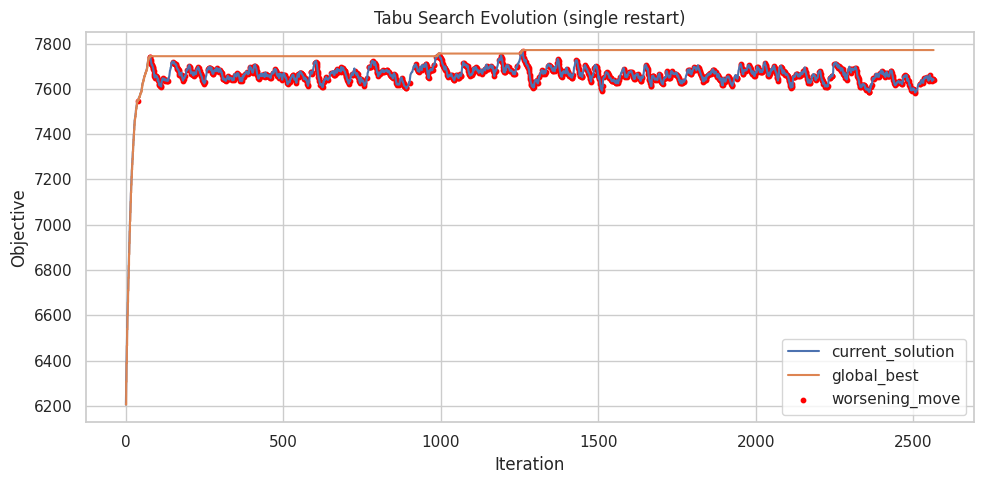

In [5]:
plt.figure(figsize=(10,5))
if not df_ts.empty:
    plt.plot(df_ts['iteration_number'], df_ts['current_solution_objective'], label='current_solution')
    plt.step(df_ts['iteration_number'], df_ts['global_best_objective'], where='post', label='global_best')
    worsens = df_ts[df_ts['was_worsening_move']]
    if not worsens.empty:
        plt.scatter(worsens['iteration_number'], worsens['current_solution_objective'], color='red', s=10, label='worsening_move')
    plt.xlabel('Iteration')
    plt.ylabel('Objective')
    plt.title('Tabu Search Evolution (single restart)')
    plt.legend()
    plt.tight_layout()
    ts_plot_path = csv_dir / 'ts_evolution_plot.png'
    plt.savefig(ts_plot_path, dpi=200)
    print(f'TS evolution plot saved to: {ts_plot_path}')
    plt.show()
else:
    print('TS evolution CSV is empty.')

TS evolution plot saved to: ../csv_final/ts_evolution_plot.png


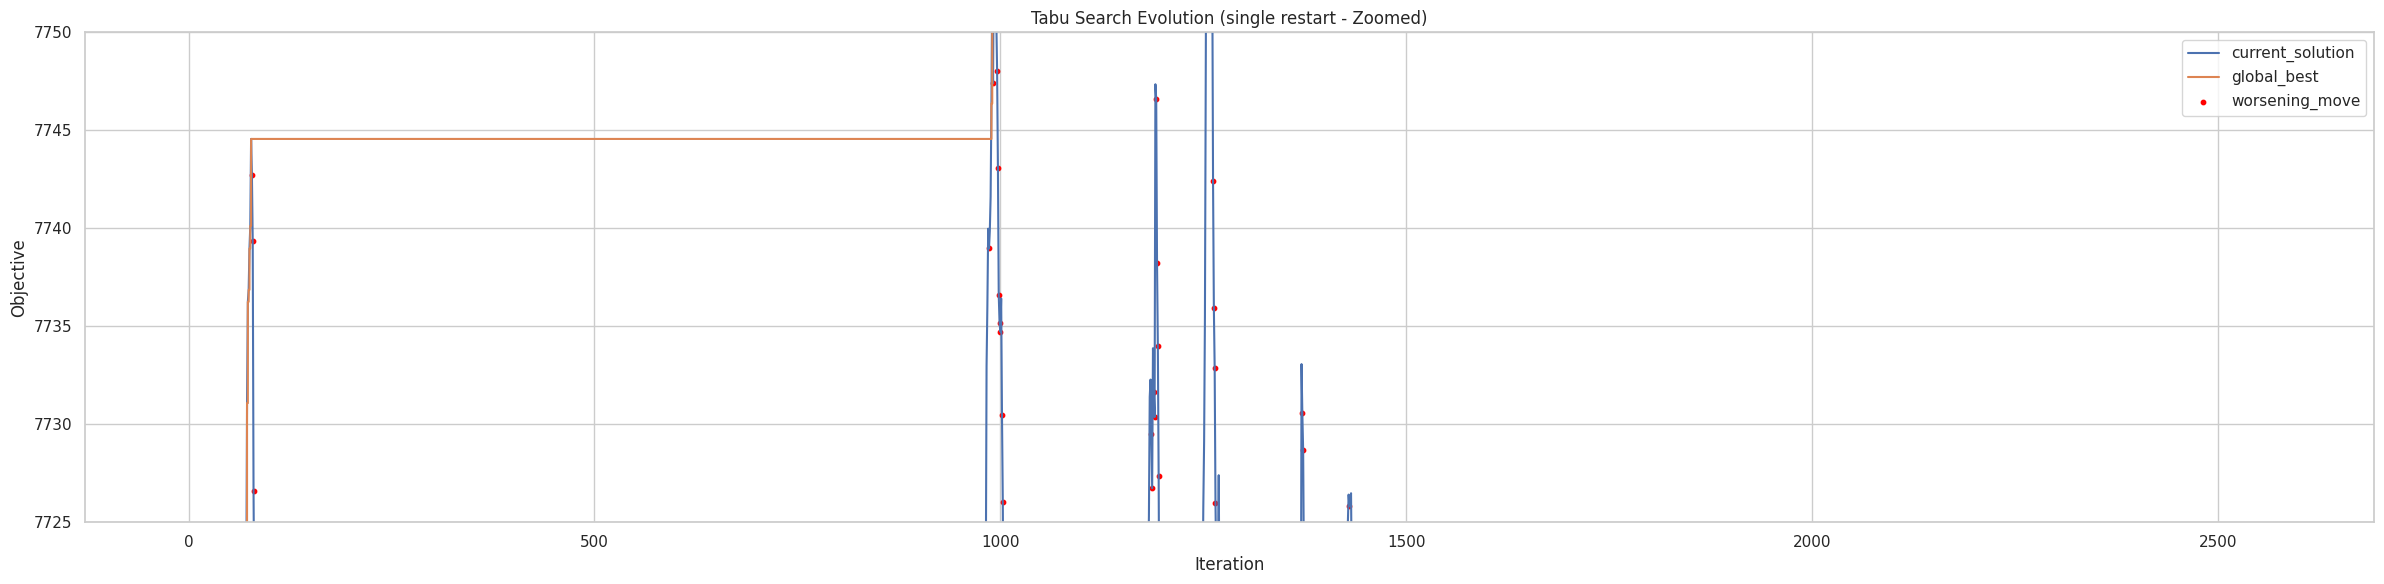

In [6]:
# ------------------------------- #
# ZOOM TABU SEARCH EVOLUTION PLOT #
# ------------------------------- #
plt.figure(figsize=(24, 6))
if not df_ts.empty:
    plt.plot(df_ts['iteration_number'], df_ts['current_solution_objective'], label='current_solution')
    plt.step(df_ts['iteration_number'], df_ts['global_best_objective'], where='post', label='global_best')
    worsens = df_ts[df_ts['was_worsening_move']]
    if not worsens.empty:
        plt.scatter(worsens['iteration_number'], worsens['current_solution_objective'], color='red', s=10, label='worsening_move')
    plt.xlabel('Iteration')
    plt.ylabel('Objective')
    plt.ylim(7725, 7750)
    plt.title('Tabu Search Evolution (single restart - Zoomed)')
    plt.legend()
    plt.tight_layout()
    ts_plot_path = csv_dir / 'ts_evolution_plot.png'
    plt.savefig(ts_plot_path, dpi=200)
    print(f'TS evolution plot saved to: {ts_plot_path}')
    plt.show()
else:
    print('TS evolution CSV is empty.')


## Notas

- Instala dependencias si es necesario: `pip install pandas matplotlib seaborn`
- Ejecuta las celdas para regenerar los PNG en `csv_final/`.